In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
fem_temp=pd.read_csv('../data/mice data.xlsx - FemTemp.csv', index_col='time (min)')
fem_act=pd.read_csv('../data/mice data.xlsx - FemAct.csv', index_col='time (min)')
male_temp=pd.read_csv('../data/mice data.xlsx - MaleTemp.csv', index_col='time (min)')
male_act=pd.read_csv('../data/mice data.xlsx - MaleAct.csv', index_col='time (min)')

In [3]:
male_temp.head()

,male1,male2,male3,male4,male5,male6
time (min),,,,,,
1,36.28,38.02,36.05,36.69,36.87,36.65
2,36.29,38.01,36.01,36.98,36.84,36.60
3,36.38,37.95,35.96,37.06,36.98,36.62
4,36.57,37.97,35.92,36.99,37.05,36.62
5,36.63,37.95,35.88,36.95,37.11,36.61


In [5]:
def shaded_trace(df, color, label, ax, ylabel=None):
    mean = df.mean(axis=1)
    std  = df.std(axis=1)
    ax.plot(df.index, mean, color=color, lw=2, label=label)
    ax.fill_between(df.index, mean - std, mean + std, color=color, alpha=0.25)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.legend(frameon=False)


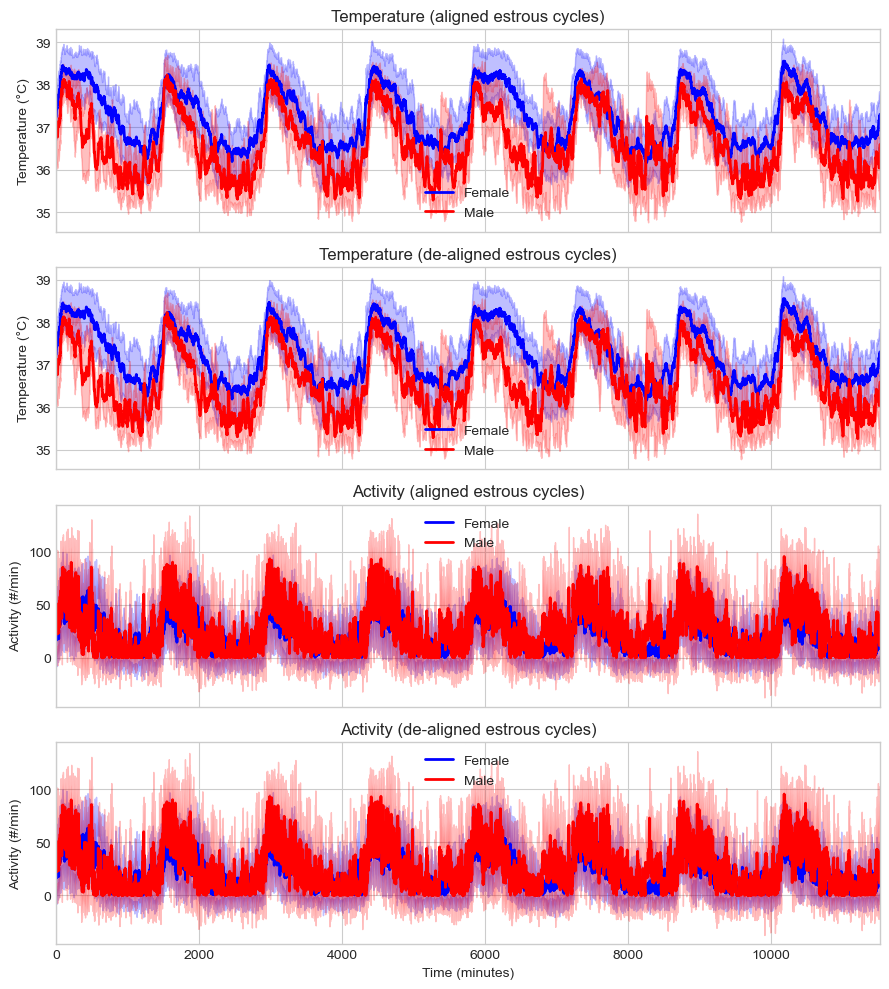

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
(ax1, ax2, ax3, ax4) = axes

shaded_trace(fem_temp, 'blue',  'Female', ax1, ylabel='Temperature (°C)')
shaded_trace(male_temp, 'red',  'Male',   ax1)
ax1.set_title('Temperature (aligned estrous cycles)')

shaded_trace(fem_temp.sample(frac=1, axis=1), 'blue',  'Female', ax2, ylabel='Temperature (°C)')
shaded_trace(male_temp.sample(frac=1, axis=1), 'red',  'Male',   ax2)
ax2.set_title('Temperature (de-aligned estrous cycles)')

shaded_trace(fem_act, 'blue',  'Female', ax3, ylabel='Activity (#/min)')
shaded_trace(male_act, 'red',  'Male',   ax3)
ax3.set_title('Activity (aligned estrous cycles)')

shaded_trace(fem_act.sample(frac=1, axis=1), 'blue',  'Female', ax4, ylabel='Activity (#/min)')
shaded_trace(male_act.sample(frac=1, axis=1), 'red',  'Male',   ax4)
ax4.set_title('Activity (de-aligned estrous cycles)')

ax4.set_xlabel('Time (minutes)')
ax4.set_xlim(0, fem_temp.index.max()) 

plt.tight_layout()
plt.show()

In [7]:
def shaded_plot(df, color, label, ax, ylabel):
    mean = df.mean(axis=1)
    std = df.std(axis=1)
    ax.plot(df.index, mean, color=color, lw=2, label=label)
    ax.fill_between(df.index, mean - std, mean + std, color=color, alpha=0.3)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(ylabel)
    ax.legend()

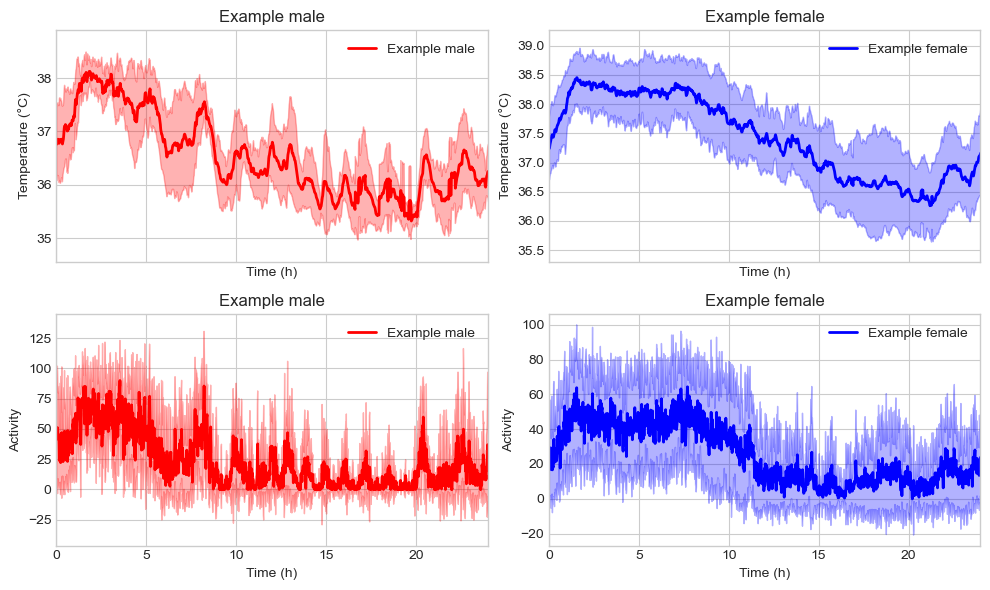

In [8]:
fem_temp.index = fem_temp.index / 60
male_temp.index = male_temp.index / 60
fem_act.index = fem_act.index / 60
male_act.index = male_act.index / 60

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
(ax1, ax2), (ax3, ax4) = axes

shaded_plot(male_temp, 'red', 'Example male', ax1, 'Temperature (°C)')
shaded_plot(fem_temp, 'blue', 'Example female', ax2, 'Temperature (°C)')

shaded_plot(male_act, 'red', 'Example male', ax3, 'Activity')
shaded_plot(fem_act, 'blue', 'Example female', ax4, 'Activity')

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlim(0, 24)
    ax.set_title(ax.get_legend_handles_labels()[1][0])

plt.tight_layout()
plt.show()

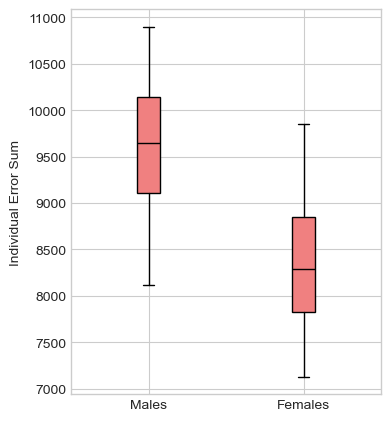

In [9]:
male_error = (male_temp - male_temp.mean()).abs().sum()
fem_error = (fem_temp - fem_temp.mean()).abs().sum()

error_df = pd.DataFrame({'Males': male_error, 'Females': fem_error})

fig, ax = plt.subplots(figsize=(4,5))
ax.boxplot(
    [error_df['Males'].dropna(), error_df['Females'].dropna()],
    tick_labels=['Males', 'Females'],
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral'),
    medianprops=dict(color='black')
)
ax.set_ylabel('Individual Error Sum')
plt.show()

In [10]:
#find the average at specfic times during the days. mice react when lights come on or off. so focus on like cycles of 12 hours and see how it varies. look for a spike of activity every 24 horus. everyon 720 mins, light should chance. light onset and offset. daily stability of change. can i show that males and females r more or less reactive of the light change?

In [11]:
def add_light_cycle(df):
    df = df.copy()
    df['cycle'] = (df.index // 720)  
    df['light_phase'] = np.where((df.index % 1440) < 720, 'Light', 'Dark')
    return df

fem_act_cycle = add_light_cycle(fem_act)
male_act_cycle = add_light_cycle(male_act)

In [12]:
def mean_by_phase(df):
    df_mean = df.drop(columns=['cycle', 'light_phase'], errors='ignore').mean(axis=1)
    df = df.assign(mean_activity=df_mean)
    return df.groupby('light_phase')['mean_activity'].mean()

print("Female mean activity by phase:\n", mean_by_phase(fem_act_cycle))
print("Male mean activity by phase:\n", mean_by_phase(male_act_cycle))


Female mean activity by phase:
 light_phase
Light    21.467697
Name: mean_activity, dtype: float64
Male mean activity by phase:
 light_phase
Light    26.172719
Name: mean_activity, dtype: float64


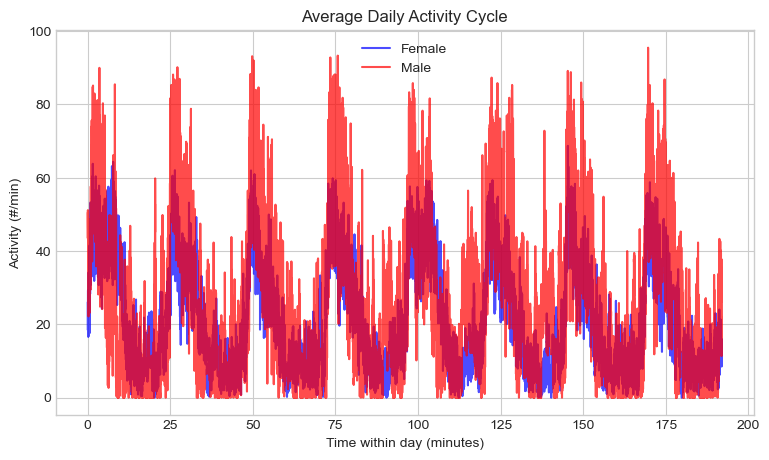

In [13]:
def plot_cycle_pattern(df, color, label, ax):
    df_mean = df.drop(columns=['cycle', 'light_phase'], errors='ignore').mean(axis=1)
    cycle_time = df.index % 1440  
    ax.plot(cycle_time, df_mean, color=color, alpha=0.7, label=label)
    ax.set_xlabel('Time within day (minutes)')
    ax.set_ylabel('Activity (#/min)')
    ax.legend(frameon=False)
    ax.set_title('Average Daily Activity Cycle')

fig, ax = plt.subplots(figsize=(9,5))
plot_cycle_pattern(fem_act_cycle, 'blue', 'Female', ax)
plot_cycle_pattern(male_act_cycle, 'red', 'Male', ax)
plt.show()


In [14]:
fem_act.index = fem_act.index * 24 * 60  
male_act.index = male_act.index * 24 * 60
def reactivity_to_light(df, window=30):
    df_mean = df.mean(axis=1)
    times = df.index.values.astype(float)
    reactivity = []

    for t in np.arange(720, times.max() - window, 720):
        before = df_mean[(times >= t - window) & (times < t)]
        after  = df_mean[(times >= t) & (times < t + window)]
        if len(before) > 0 and len(after) > 0:
            reactivity.append(after.mean() - before.mean())

    return np.mean(reactivity) if reactivity else np.nan


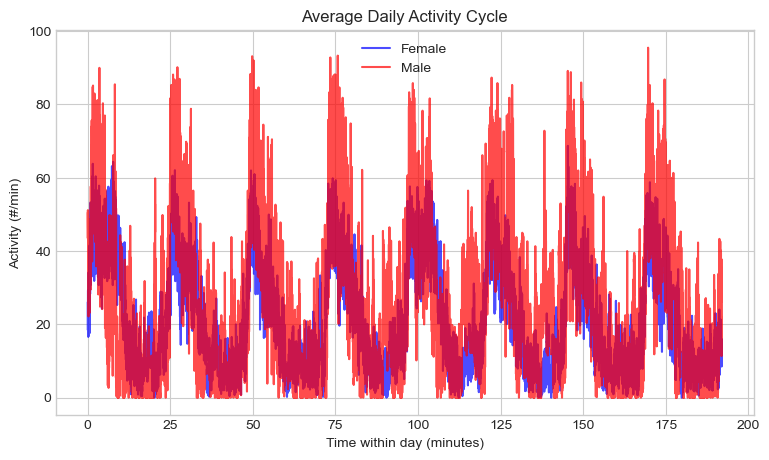

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
plot_cycle_pattern(fem_act_cycle, 'blue', 'Female', ax)
plot_cycle_pattern(male_act_cycle, 'red', 'Male', ax)
plt.show()

In [16]:
#6 hour window, lights on vs lights off, get wavelit distance between the two, and the average distance. average of averages for male and females. subtract those two and figure out the differences. what does that signify? isolate windows where the stransition of lights on or off happens

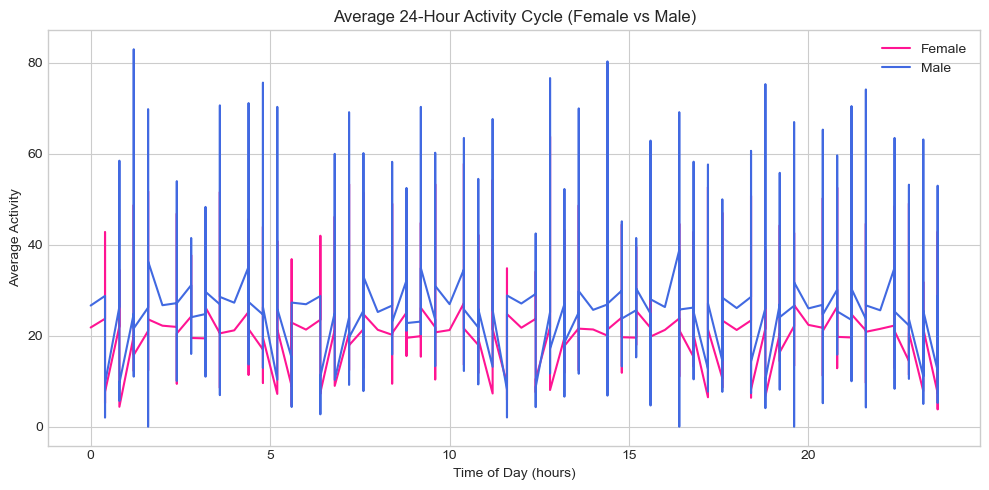

In [17]:
fem = fem_act.copy()
fem['minute_of_day'] = fem.index % 1440
fem_cycle = fem.groupby('minute_of_day').mean()
fem_cycle['mean'] = fem_cycle.mean(axis=1)

male = male_act.copy()
male['minute_of_day'] = male.index % 1440
male_cycle = male.groupby('minute_of_day').mean()
male_cycle['mean'] = male_cycle.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(fem_cycle.index / 60, fem_cycle['mean'], label='Female', color='deeppink')
plt.plot(male_cycle.index / 60, male_cycle['mean'], label='Male', color='royalblue')

plt.xlabel('Time of Day (hours)')
plt.ylabel('Average Activity')
plt.title('Average 24-Hour Activity Cycle (Female vs Male)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
import pywt

def extract_transition_windows(df, window=60):
    df = df.copy()
    minutes_per_day = 1440
    n_days = len(df) // minutes_per_day

    on_windows = []
    off_windows = []

    for d in range(n_days):
        start = d * minutes_per_day
        on_idx = np.arange(start, start + window*2)
        off_idx = np.arange(start + 720 - window, start + 720 + window)
        on_windows.append(df.iloc[on_idx])
        off_windows.append(df.iloc[off_idx])

    return {'on': pd.concat(on_windows), 'off': pd.concat(off_windows)}

fem_onoff = extract_transition_windows(fem_act)

def compute_cwt_signals(df, wavelet='morl'):
    cwt_results = {}
    for col in df.columns:
        signal = df[col].values
        coeffs, freqs = pywt.cwt(signal, scales=np.arange(1, 128), wavelet=wavelet)
        cwt_results[col] = (coeffs, freqs)
    return cwt_results

fem_cwt_on = compute_cwt_signals(fem_onoff['on'])

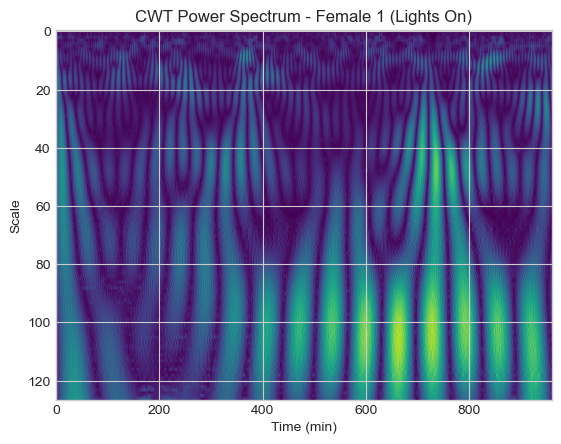

In [19]:

coeffs, freqs = fem_cwt_on['fem1']
plt.imshow(np.abs(coeffs), aspect='auto', cmap='viridis')
plt.title('CWT Power Spectrum - Female 1 (Lights On)')
plt.xlabel('Time (min)')
plt.ylabel('Scale')
plt.show()

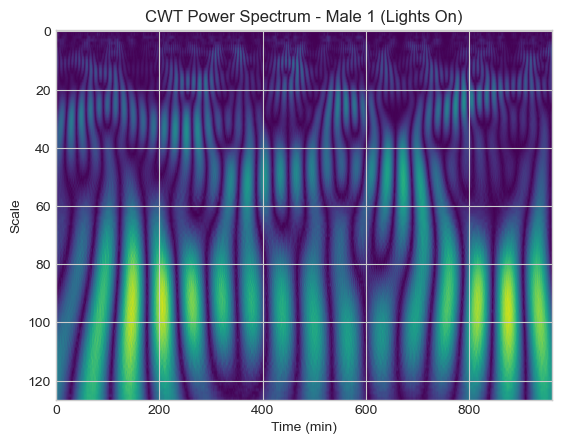

In [20]:
male_onoff = extract_transition_windows(male_act)
male_cwt_on = compute_cwt_signals(male_onoff['on'])

coeffs, freqs = male_cwt_on['male1']
plt.imshow(np.abs(coeffs), aspect='auto', cmap='viridis')
plt.title('CWT Power Spectrum - Male 1 (Lights On)')
plt.xlabel('Time (min)')
plt.ylabel('Scale')
plt.show()

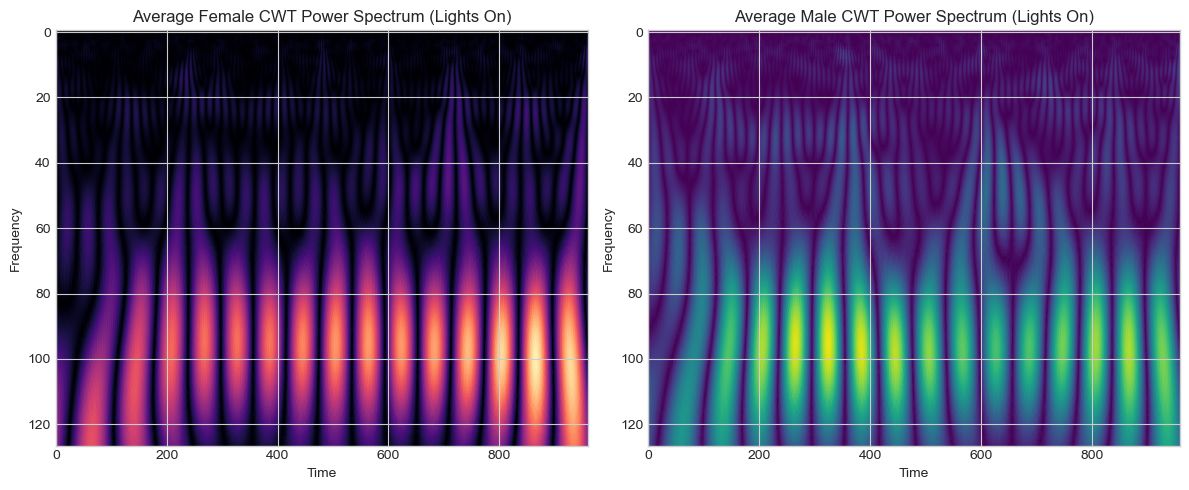

In [21]:
fem_coeffs = np.stack([coeffs for coeffs, freqs in fem_cwt_on.values()])
male_coeffs = np.stack([coeffs for coeffs, freqs in male_cwt_on.values()])

fem_mean_coeffs = np.mean(fem_coeffs, axis=0)
male_mean_coeffs = np.mean(male_coeffs, axis=0)

freqs = freqs

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.abs(fem_mean_coeffs), aspect='auto', cmap='magma')
plt.title('Average Female CWT Power Spectrum (Lights On)')
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.imshow(np.abs(male_mean_coeffs), aspect='auto', cmap='viridis')
plt.title('Average Male CWT Power Spectrum (Lights On)')
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

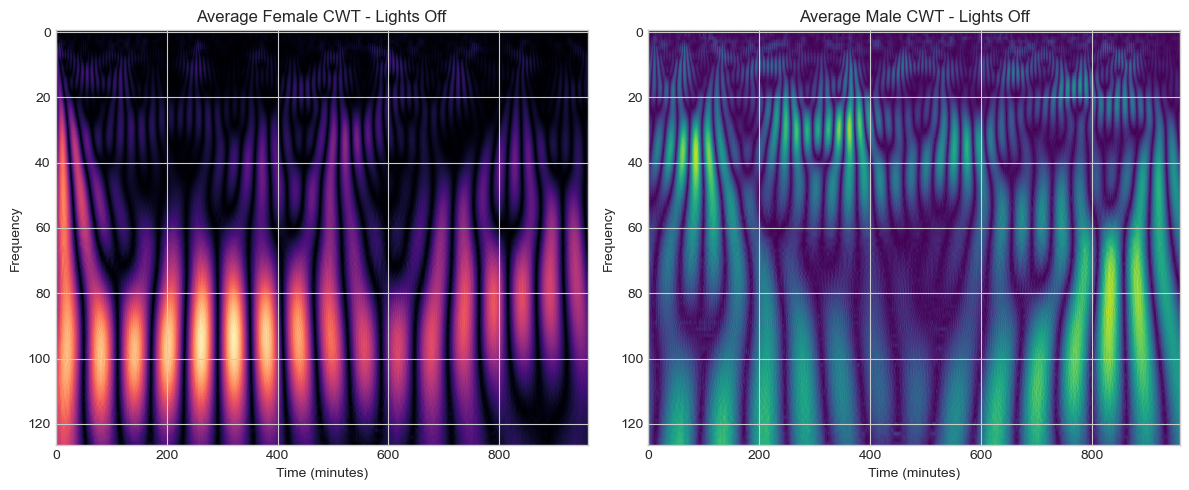

In [48]:
fem_onoff = extract_transition_windows(fem_act, window=60)
male_onoff = extract_transition_windows(male_act, window=60)
fem_cwt_off = compute_cwt_signals(fem_onoff['off'])
male_cwt_off = compute_cwt_signals(male_onoff['off'])
fem_coeffs_off = np.stack([coeffs for coeffs, freqs in fem_cwt_off.values()])
male_coeffs_off = np.stack([coeffs for coeffs, freqs in male_cwt_off.values()])

fem_mean_coeffs_off = np.mean(fem_coeffs_off, axis=0)
male_mean_coeffs_off = np.mean(male_coeffs_off, axis=0)

freqs = list(fem_cwt_off.values())[0][1]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.abs(fem_mean_coeffs_off), aspect='auto', cmap='magma')
plt.title('Average Female CWT - Lights Off')
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.imshow(np.abs(male_mean_coeffs_off), aspect='auto', cmap='viridis')
plt.title('Average Male CWT - Lights Off')
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
